In [1]:
!pip install gtts -q
!pip install opencv-python-headless -q

import os
import glob
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.utils import Sequence

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models as torch_models
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

from gtts import gTTS
from IPython.display import Audio, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# CELL 3 — PATHS + CONFIG
# ============================================================

ZIP_PATH      = "/content/new_ML_DATASET.zip"
EXTRACT_PATH  = "/content/sign_language_dataset"
TRAIN_PATH    = "/content/sign_language_dataset/new_ML_DATASET/Train"
ENHANCED_PATH = "/content/sign_language_dataset_enhanced"
SAVE_DIR      = "/content/models"

IMG_SIZE  = (224, 224)
BATCH     = 64
EPOCHS    = 5
valid_ext = ('.jpg', '.jpeg', '.png')

os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# CELL 4 — EXTRACT ZIP
# ============================================================

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_PATH)
print("✅ Extracted to:", EXTRACT_PATH)
print("Train path exists:", os.path.exists(TRAIN_PATH))

Extracting dataset...
✅ Extracted to: /content/sign_language_dataset
Train path exists: True


In [5]:
# CELL 5 — CLEAN DATASET
# ============================================================

def clean_dataset(path):
    removed = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            if not f.lower().endswith(valid_ext):
                os.remove(os.path.join(root, f))
                removed += 1
    print("Removed files:", removed)

def check_dataset(path):
    classes = sorted([
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d))
    ])
    print(f"Classes ({len(classes)}): {classes}")
    for c in classes:
        print(f"  {c} : {len(os.listdir(os.path.join(path, c)))} images")

clean_dataset(TRAIN_PATH)
check_dataset(TRAIN_PATH)

Removed files: 0
Classes (7): ['A', 'E', 'H', 'I', 'N', 'O', 'T']
  A : 1500 images
  E : 1381 images
  H : 1573 images
  I : 1553 images
  N : 1535 images
  O : 1548 images
  T : 1579 images


In [6]:
# ============================================================
# CELL 6 — SMART IMAGE ENHANCEMENT (FIXED)
# ============================================================

def enhance(pil_img: Image.Image) -> Image.Image:

    img = cv2.cvtColor(
        np.array(pil_img.convert("RGB")),
        cv2.COLOR_RGB2BGR
    )

    # 1. Very tiny denoise
    img = cv2.fastNlMeansDenoisingColored(
        img,
        None,
        h=2,
        hColor=2,
        templateWindowSize=5,
        searchWindowSize=15
    )

    # 2. Gentle CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=1.1,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    img = cv2.cvtColor(
        cv2.merge([l, a, b]),
        cv2.COLOR_LAB2BGR
    )

    # 3. Softer sharpening
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=1.2)

    img = cv2.addWeighted(
        img,
        1.15,
        blur,
        -0.15,
        0
    )

    # 4. Remove strong gamma effect
    gamma = 1.02

    table = np.array([
        ((i / 255.0) ** (1.0 / gamma)) * 255
        for i in range(256)
    ]).astype("uint8")

    img = cv2.LUT(img, table)

    return Image.fromarray(
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    )

In [7]:
# CELL 7 — PRE-ENHANCE DATASET
# ============================================================

def preprocess_dataset(src, dst):
    if os.path.exists(dst):
        print("✅ Enhanced dataset already exists, skipping...")
        return
    print("⚡ Pre-enhancing all images once...")
    total = 0
    for cls in sorted(os.listdir(src)):
        cls_src = os.path.join(src, cls)
        cls_dst = os.path.join(dst, cls)
        if not os.path.isdir(cls_src):
            continue
        os.makedirs(cls_dst, exist_ok=True)
        for fname in os.listdir(cls_src):
            if not fname.lower().endswith(valid_ext):
                continue
            try:
                pil = Image.open(os.path.join(cls_src, fname)).convert("RGB")
                enh = enhance(pil)
                enh.save(os.path.join(cls_dst, fname))
                total += 1
            except Exception:
                continue
    print(f"✅ Done! {total} images enhanced → {dst}")

preprocess_dataset(TRAIN_PATH, ENHANCED_PATH)


TRAIN_PATH = ENHANCED_PATH


⚡ Pre-enhancing all images once...
✅ Done! 10669 images enhanced → /content/sign_language_dataset_enhanced


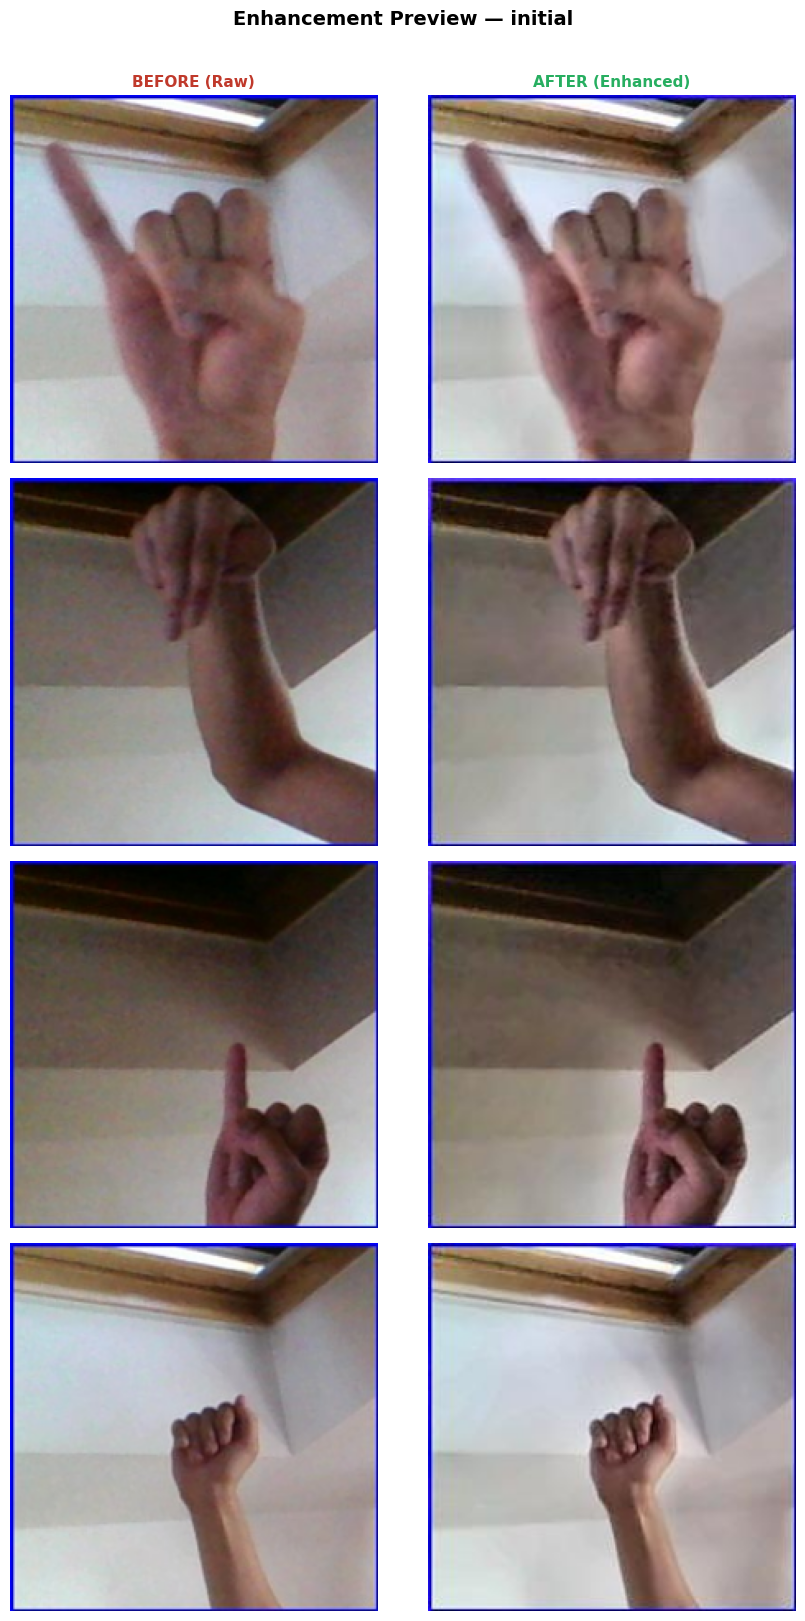

In [13]:
# ============================================================
# CELL 8 — BEFORE / AFTER PREVIEW
# ============================================================

def show_before_after(dataset_path, n=4, title_tag=""):

    imgs = (
        glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True) +
        glob.glob(os.path.join(dataset_path, "**", "*.png"), recursive=True) +
        glob.glob(os.path.join(dataset_path, "**", "*.jpeg"), recursive=True)
    )

    if not imgs:
        print("No images found in:", dataset_path)
        return

    chosen = random.sample(imgs, min(n, len(imgs)))

    # عمودين بس
    fig, axes = plt.subplots(n, 2, figsize=(9, n * 4))

    fig.suptitle(
        f"Enhancement Preview — {title_tag}",
        fontsize=14,
        fontweight='bold',
        y=1.01
    )

    col_titles = ["BEFORE (Raw)", "AFTER (Enhanced)"]

    colors = ['#c0392b', '#27ae60']

    for c, ct in enumerate(col_titles):
        axes[0][c].set_title(
            ct,
            fontsize=11,
            fontweight='bold',
            color=colors[c]
        )

    orig_path = "/content/sign_language_dataset/new_ML_DATASET/Train"

    for row, enh_path in enumerate(chosen):

        rel = os.path.relpath(enh_path, TRAIN_PATH)

        raw_path = os.path.join(orig_path, rel)

        try:
            raw = Image.open(raw_path).convert("RGB")

        except Exception:
            raw = Image.open(enh_path).convert("RGB")

        enh = Image.open(enh_path).convert("RGB")

        cls = os.path.basename(os.path.dirname(enh_path))

        raw_np = np.array(raw.resize((224, 224)))

        enh_np = np.array(enh.resize((224, 224)))

        # BEFORE
        axes[row][0].imshow(raw_np)

        axes[row][0].set_ylabel(
            f"class: {cls}",
            fontsize=9,
            rotation=90,
            labelpad=4
        )

        # AFTER
        axes[row][1].imshow(enh_np)

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"/content/before_after_{title_tag}.png",
        dpi=130,
        bbox_inches='tight'
    )

    plt.show()


show_before_after(TRAIN_PATH, n=4, title_tag="initial")

In [ ]:
# CELL 9 — FAST KERAS GENERATOR
# ============================================================

class FastDataGenerator(Sequence):
    def __init__(self, directory, img_size=(224,224), batch_size=64,
                 subset='training', validation_split=0.2, seed=42, shuffle=True):
        self.img_size    = img_size
        self.batch_size  = batch_size
        self.shuffle     = shuffle
        self.class_names = sorted([
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}

        all_samples = []
        for cls in self.class_names:
            cls_path = os.path.join(directory, cls)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(valid_ext):
                    all_samples.append(
                        (os.path.join(cls_path, fname), self.class_to_idx[cls])
                    )

        random.seed(seed)
        random.shuffle(all_samples)
        split = int(len(all_samples) * (1 - validation_split))
        self.samples = all_samples[:split] if subset == 'training' else all_samples[split:]
        self.indices = list(range(len(self.samples)))
        self.on_epoch_end()

    def __len__(self):
        return max(1, len(self.samples) // self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X, Y = [], []
        for i in batch_idx:
            path, label = self.samples[i]
            try:
                # ✅ No enhance() — already done offline
                pil = Image.open(path).convert("RGB")
                arr = np.array(pil.resize(self.img_size)) / 255.0
                X.append(arr)
                Y.append(label)
            except Exception:
                continue
        return (np.array(X, dtype=np.float32),
                tf.keras.utils.to_categorical(Y, num_classes=len(self.class_names)))

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.indices)


In [ ]:
# CELL 10 — FAST PYTORCH DATASET
# ============================================================

class FastTorchDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # ✅ No enhance() — already done offline
        pil = Image.open(path).convert("RGB")
        if self.transform:
            pil = self.transform(pil)
        return pil, label

In [ ]:
# CELL 11 — BUILD ALL GENERATORS / LOADERS
# ============================================================

# ── Keras ────────────────────────────────────────────────────
train_data = FastDataGenerator(
    TRAIN_PATH, img_size=IMG_SIZE, batch_size=BATCH,
    subset='training', validation_split=0.2, shuffle=True
)
val_data = FastDataGenerator(
    TRAIN_PATH, img_size=IMG_SIZE, batch_size=BATCH,
    subset='validation', validation_split=0.2, shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)
print(f"✅ Classes ({num_classes}): {class_names}")
print(f"   Train batches: {len(train_data)} | Val batches: {len(val_data)}")

# ── PyTorch samples ──────────────────────────────────────────
all_samples = []
for cls in class_names:
    cls_path = os.path.join(TRAIN_PATH, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(valid_ext):
            all_samples.append(
                (os.path.join(cls_path, fname), train_data.class_to_idx[cls])
            )

random.seed(SEED)
random.shuffle(all_samples)
split      = int(0.8 * len(all_samples))
train_samp = all_samples[:split]
val_samp   = all_samples[split:]

# ── PyTorch transforms ───────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_loader = DataLoader(
    FastTorchDataset(train_samp, train_tf),
    batch_size=BATCH, shuffle=True,
    num_workers=4, pin_memory=True,   # ⚡
    persistent_workers=True
)
val_loader = DataLoader(
    FastTorchDataset(val_samp, eval_tf),
    batch_size=BATCH, shuffle=False,
    num_workers=4, pin_memory=True,   # ⚡
    persistent_workers=True
)
print(f"   PyTorch — Train: {len(train_samp)} | Val: {len(val_samp)}")

✅ Classes (7): ['A', 'E', 'H', 'I', 'N', 'O', 'T']
   Train batches: 133 | Val batches: 33
   PyTorch — Train: 8535 | Val: 2134


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# CELL 12 — DEFINE ALL 5 MODELS
# ============================================================

# ── 1. Custom CNN (Keras) ────────────────────────────────────
cnn = models.Sequential([
    Input(shape=(224, 224, 3)),
    layers.Conv2D(32,  3, padding='same', activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(64,  3, padding='same', activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
], name="Custom_CNN")
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy', metrics=['accuracy'])

# ── 2. MobileNetV2 (Keras) ───────────────────────────────────
base_mob = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_mob.trainable = False
model_mob = tf.keras.Sequential([
    base_mob,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name="MobileNetV2")
model_mob.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# ── 3. EfficientNetB0 (Keras) ────────────────────────────────
base_eff = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_eff.trainable = False
model_eff = tf.keras.Sequential([
    base_eff,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name="EfficientNetB0")
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# ── 4. ResNet18 (PyTorch) ─────────────────────────────────────
resnet_model = torch_models.resnet18(weights=torch_models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model = resnet_model.to(device)

# ── 5. ConvNeXt Tiny (PyTorch) ───────────────────────────────
convnext_model = torch_models.convnext_tiny(weights=torch_models.ConvNeXt_Tiny_Weights.DEFAULT)
convnext_model.classifier[2] = nn.Linear(convnext_model.classifier[2].in_features, num_classes)
convnext_model = convnext_model.to(device)

In [ ]:
# CELL 13 — TRAIN HELPERS
# ============================================================

def plot_history(history, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Curves — {name}", fontweight='bold')
    ax1.plot(history.history['accuracy'],     marker='o', label='Train')
    ax1.plot(history.history['val_accuracy'], marker='s', label='Val')
    ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'],         marker='o', label='Train')
    ax2.plot(history.history['val_loss'],     marker='s', label='Val')
    ax2.set_title("Loss"); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(f"/content/curves_{name}.png", dpi=120)
    plt.show()


def train_torch(model, name, epochs=EPOCHS, lr=1e-4):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr * 10,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.2
    )
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
        train_acc = correct / total

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        val_acc = correct / total

        mark = " ✅" if val_acc > best_acc else ""
        print(f"[{name}] ep {epoch+1:>2}/{epochs} | "
              f"train {train_acc:.3f} | val {val_acc:.3f}{mark}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{SAVE_DIR}/{name}.pth")

    model.load_state_dict(torch.load(f"{SAVE_DIR}/{name}.pth", map_location=device))
    print(f"[{name}] ✅ Best val_acc: {best_acc:.4f}")
    return model


══ 1/5  Custom CNN ══


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 50s 285ms/step - accuracy: 0.5266 - loss: 5.1138 - val_accuracy: 0.1567 - val_loss: 55.6215
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 36s 268ms/step - accuracy: 0.6384 - loss: 0.8681 - val_accuracy: 0.1813 - val_loss: 21.4566
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 34s 258ms/step - accuracy: 0.7016 - loss: 0.7514 - val_accuracy: 0.2884 - val_loss: 13.3009
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.7387 - loss: 0.6713 - val_accuracy: 0.7178 - val_loss: 0.7339
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 35s 266ms/step - accuracy: 0.7715 - loss: 0.5781 - val_accuracy: 0.8954 - val_loss: 0.2226


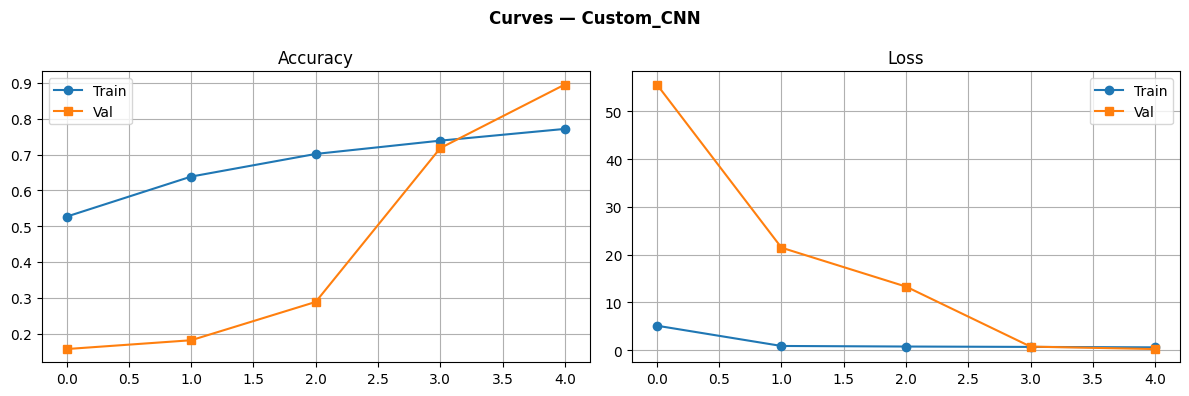


══ 2/5  MobileNetV2 ══
Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 58s 299ms/step - accuracy: 0.6221 - loss: 1.1145 - val_accuracy: 0.9446 - val_loss: 0.4177
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 37s 275ms/step - accuracy: 0.9179 - loss: 0.3538 - val_accuracy: 0.9777 - val_loss: 0.1846
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 36s 268ms/step - accuracy: 0.9615 - loss: 0.1966 - val_accuracy: 0.9882 - val_loss: 0.1071
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 34s 252ms/step - accuracy: 0.9767 - loss: 0.1290 - val_accuracy: 0.9905 - val_loss: 0.0743
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 36s 273ms/step - accuracy: 0.9841 - loss: 0.0955 - val_accuracy: 0.9924 - val_loss: 0.0559


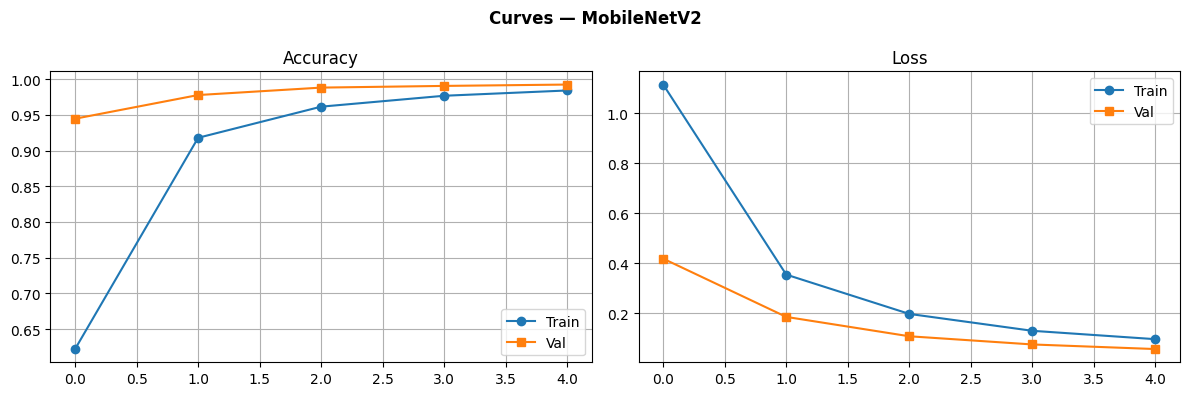


══ 3/5  EfficientNetB0 ══
Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 69s 330ms/step - accuracy: 0.1503 - loss: 2.1172 - val_accuracy: 0.1562 - val_loss: 1.9458
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 37s 275ms/step - accuracy: 0.1471 - loss: 2.0270 - val_accuracy: 0.2098 - val_loss: 1.9459
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 38s 284ms/step - accuracy: 0.1508 - loss: 1.9813 - val_accuracy: 0.1340 - val_loss: 1.9461
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.1582 - loss: 1.9604 - val_accuracy: 0.1340 - val_loss: 1.9462
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 37s 277ms/step - accuracy: 0.1559 - loss: 1.9513 - val_accuracy: 0.1349 - val_loss: 1.9464


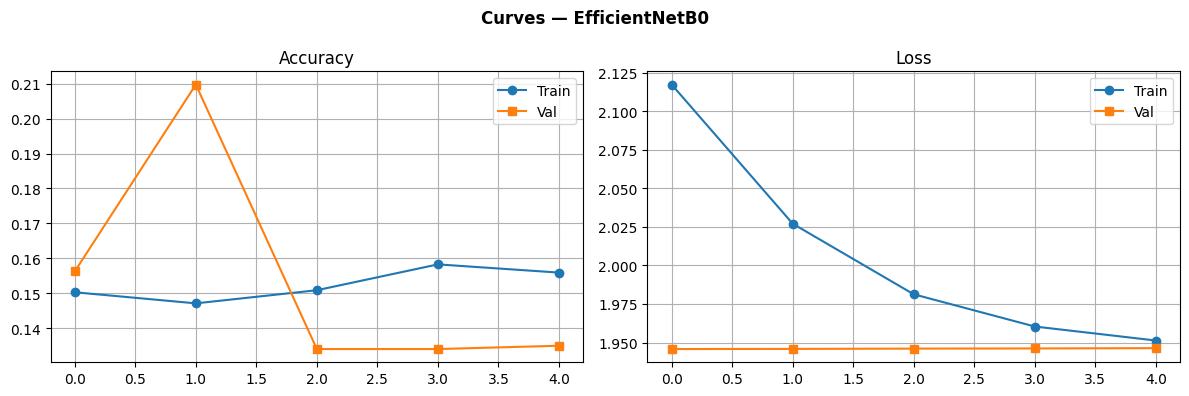


══ 4/5  ResNet18 ══


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[ResNet18] ep  1/5 | train 0.927 | val 1.000 ✅
[ResNet18] ep  2/5 | train 1.000 | val 1.000
[ResNet18] ep  3/5 | train 1.000 | val 1.000
[ResNet18] ep  4/5 | train 1.000 | val 1.000
[ResNet18] ep  5/5 | train 1.000 | val 1.000
[ResNet18] ✅ Best val_acc: 1.0000

══ 5/5  ConvNeXt Tiny ══
[ConvNeXt_Tiny] ep  1/5 | train 0.941 | val 1.000 ✅
[ConvNeXt_Tiny] ep  2/5 | train 0.669 | val 0.133
[ConvNeXt_Tiny] ep  3/5 | train 0.207 | val 0.292
[ConvNeXt_Tiny] ep  4/5 | train 0.417 | val 0.564
[ConvNeXt_Tiny] ep  5/5 | train 0.682 | val 0.772
[ConvNeXt_Tiny] ✅ Best val_acc: 1.0000


In [ ]:
# CELL 14 — TRAIN ALL 5
# ============================================================

print("\n══ 1/5  Custom CNN ══")
hist_cnn = cnn.fit(train_data, validation_data=val_data, epochs=EPOCHS, verbose=1)
plot_history(hist_cnn, "Custom_CNN")

print("\n══ 2/5  MobileNetV2 ══")
hist_mob = model_mob.fit(train_data, validation_data=val_data, epochs=EPOCHS, verbose=1)
plot_history(hist_mob, "MobileNetV2")

print("\n══ 3/5  EfficientNetB0 ══")
hist_eff = model_eff.fit(train_data, validation_data=val_data, epochs=EPOCHS, verbose=1)
plot_history(hist_eff, "EfficientNetB0")

print("\n══ 4/5  ResNet18 ══")
resnet_model = train_torch(resnet_model, "ResNet18")

print("\n══ 5/5  ConvNeXt Tiny ══")
convnext_model = train_torch(convnext_model, "ConvNeXt_Tiny")

In [ ]:
# CELL 15 — EVALUATE ALL 5
# ============================================================

def evaluate_keras(model, data, name):
    _, acc = model.evaluate(data, verbose=0)
    print(f"{name:20s} → {acc:.4f}")
    return acc

def evaluate_torch(model, name):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    acc = correct / total
    print(f"{name:20s} → {acc:.4f}")
    return acc

print("\n📊 Validation Accuracy:")
results = {
    "Custom_CNN":     evaluate_keras(cnn,            val_data, "Custom_CNN"),
    "MobileNetV2":    evaluate_keras(model_mob,      val_data, "MobileNetV2"),
    "EfficientNetB0": evaluate_keras(model_eff,      val_data, "EfficientNetB0"),
    "ResNet18":       evaluate_torch(resnet_model,   "ResNet18"),
    "ConvNeXt_Tiny":  evaluate_torch(convnext_model, "ConvNeXt_Tiny"),
}



📊 Validation Accuracy:
Custom_CNN           → 0.8954
MobileNetV2          → 0.9924
EfficientNetB0       → 0.1349
ResNet18             → 1.0000
ConvNeXt_Tiny        → 1.0000



🏆 Best Model: ResNet18  (1.0000)

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       288
           E       1.00      1.00      1.00       283
           H       1.00      1.00      1.00       290
           I       1.00      1.00      1.00       331
           N       1.00      1.00      1.00       319
           O       1.00      1.00      1.00       311
           T       1.00      1.00      1.00       312

    accuracy                           1.00      2134
   macro avg       1.00      1.00      1.00      2134
weighted avg       1.00      1.00      1.00      2134



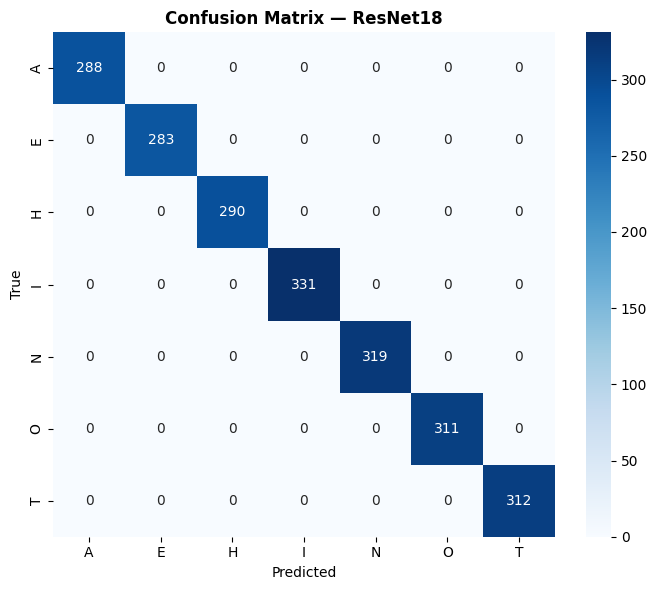

In [ ]:
# ============================================================
# CELL 16 — BEST MODEL → REPORT + CONFUSION MATRIX
# ============================================================

keras_map = {"Custom_CNN": cnn, "MobileNetV2": model_mob, "EfficientNetB0": model_eff}
torch_map = {"ResNet18": resnet_model, "ConvNeXt_Tiny": convnext_model}

best_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_name}  ({results[best_name]:.4f})")

all_preds, all_true = [], []

if best_name in keras_map:
    ref = FastDataGenerator(
        TRAIN_PATH, img_size=IMG_SIZE, batch_size=BATCH,
        subset='validation', validation_split=0.2, shuffle=False
    )
    for i in range(len(ref)):
        X, Y = ref[i]
        p = keras_map[best_name].predict(X, verbose=0)
        all_preds.extend(np.argmax(p, axis=1))
        all_true.extend(np.argmax(Y, axis=1))
else:
    m = torch_map[best_name]
    m.eval()
    with torch.no_grad():
        for x, y in val_loader:
            out = m(x.to(device))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(y.numpy())

print("\nClassification Report:")
print(classification_report(all_true, all_preds,
                             target_names=class_names, zero_division=0))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(max(7, num_classes), max(5, num_classes - 1)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix — {best_name}", fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=120)
plt.show()



         Model  Accuracy
 ConvNeXt_Tiny  1.000000
      ResNet18  1.000000
   MobileNetV2  0.992424
    Custom_CNN  0.895360
EfficientNetB0  0.134943


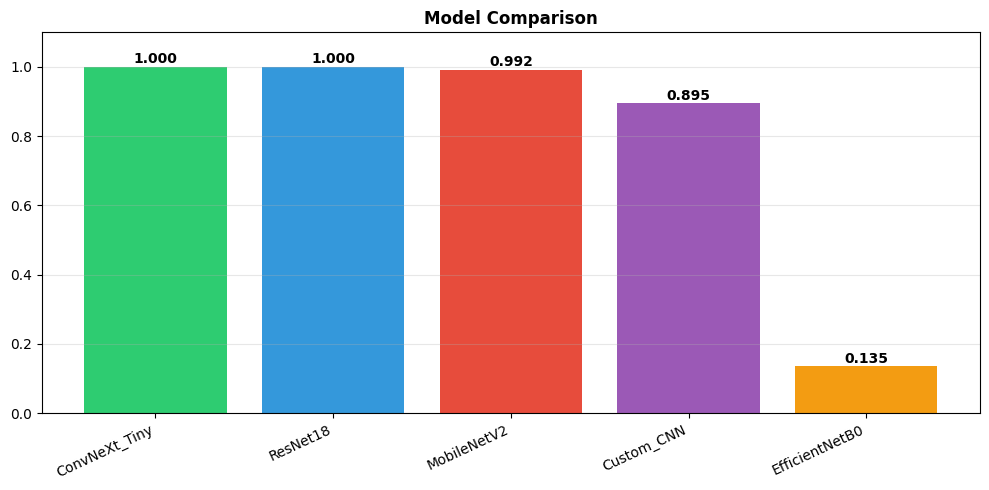

In [ ]:
# ============================================================
# CELL 17 — COMPARISON CHART
# ============================================================

df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
df = df.sort_values("Accuracy", ascending=False)
print(df.to_string(index=False))

colors = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12']
plt.figure(figsize=(10, 5))
bars = plt.bar(df["Model"], df["Accuracy"], color=colors)
for bar, acc in zip(bars, df["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.3f}", ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.1)
plt.title("Model Comparison", fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/comparison.png", dpi=120)
plt.show()



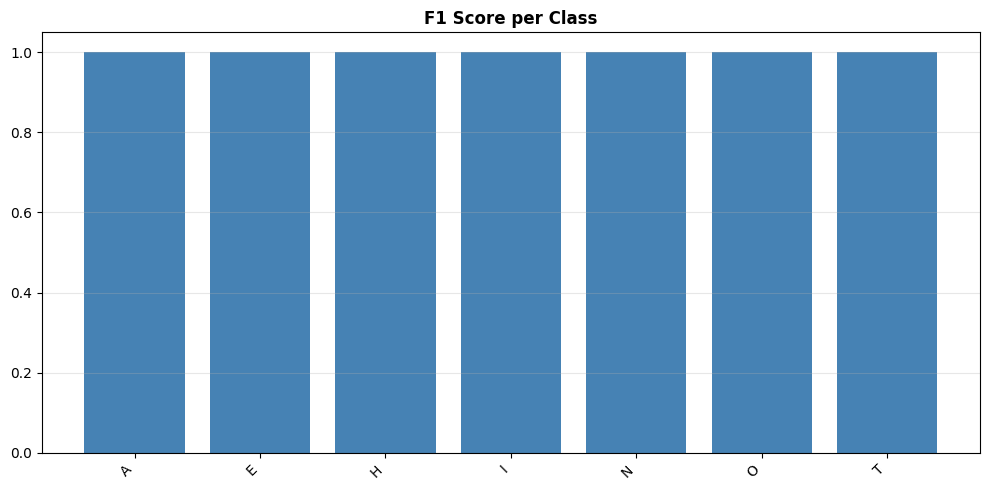

In [ ]:
# ============================================================
# CELL 18 — F1 PER CLASS
# ============================================================

report_dict = classification_report(
    all_true, all_preds, target_names=class_names,
    output_dict=True, zero_division=0
)
f1_scores = [report_dict[c]['f1-score'] for c in class_names]

plt.figure(figsize=(10, 5))
plt.bar(class_names, f1_scores, color='steelblue')
plt.title("F1 Score per Class", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/f1_per_class.png", dpi=120)
plt.show()

In [ ]:
# ============================================================
# CELL 19 — ERROR ANALYSIS
# ============================================================

errors = np.where(np.array(all_preds) != np.array(all_true))[0]
print(f"Wrong predictions : {len(errors)}")
print(f"Error rate        : {len(errors)/len(all_true):.2%}")


Wrong predictions : 0
Error rate        : 0.00%


In [ ]:
# CELL 20 — gTTS SPEAK
# ============================================================

def speak(word: str):
    tts = gTTS(word.lower(), lang='en')
    tts.save("/content/word_output.mp3")
    return Audio("/content/word_output.mp3", autoplay=True)


In [ ]:
# CELL 21 — PREDICT LETTER (Keras + PyTorch)
# ============================================================

def predict_letter(model, img_path):
    # ✅ enhance على صور الـ prediction بردو
    pil = Image.open(img_path).convert("RGB")
    enh = enhance(pil)

    if isinstance(model, nn.Module):
        t = eval_tf(enh).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(t), 1)[0].cpu().numpy()
    else:
        arr   = np.array(enh.resize(IMG_SIZE)) / 255.0
        arr   = np.expand_dims(arr, axis=0)
        probs = model.predict(arr, verbose=0)[0]

    letter = class_names[np.argmax(probs)]
    conf   = float(np.max(probs))
    print(f"  {os.path.basename(img_path):30s} → {letter}  ({conf:.1%})")
    return letter

In [ ]:
# CELL 22 — PREDICT WORD + SPEAK
# ============================================================

best_model_obj = keras_map.get(best_name) or torch_map.get(best_name)

def predict_word(image_paths: list, model=None):
    if model is None:
        model = best_model_obj
    letters = [predict_letter(model, p) for p in image_paths]
    word    = "".join(letters)
    print(f"\n📝 Predicted Word: {word}")
    return word, speak(word)

In [ ]:
# CELL 23 — RUN EXAMPLE
# ============================================================

imgs = [
    "/content/hh.jpeg",
    "/content/I_test.jpg"
]

word, audio = predict_word(imgs)
display(audio)

  hh.jpeg                        → H  (75.7%)
  I_test.jpg                     → I  (93.8%)

📝 Predicted Word: HI


In [ ]:
# CELL 23 — RUN EXAMPLE
# ============================================================

imgs = [
    "/content/N_test.jpg",
    "/content/O_test.jpg"
]

word, audio = predict_word(imgs)
display(audio)

  N_test.jpg                     → N  (95.8%)
  O_test.jpg                     → O  (93.2%)

📝 Predicted Word: NO


In [ ]:
# CELL 24 — SUMMARY
# ============================================================

print(f"""
⚡ SPEED OPTIMIZATIONS APPLIED:
  ✅ Pre-enhanced images (offline, once)  → ~60% faster
  ✅ BATCH = 64                           → GPU full utilization
  ✅ EPOCHS = 5                           → fixed as requested
  ✅ num_workers = 4 + persistent         → faster data loading
  ✅ non_blocking transfers               → GPU pipeline overlap

PATHS:
  ZIP       : {ZIP_PATH}
  Extracted : {EXTRACT_PATH}
  Enhanced  : {ENHANCED_PATH}
  Models    : {SAVE_DIR}

MODELS:
  1. Custom CNN      → Keras   baseline
  2. MobileNetV2     → Keras   fast + accurate
  3. EfficientNetB0  → Keras   strong ceiling
  4. ResNet18        → PyTorch solid extractor
  5. ConvNeXt Tiny   → PyTorch highest capacity

🏆 Best this run : {best_name} → {results[best_name]:.4f}
⏱️  Expected time : 20–35 min on T4/A100
""")


⚡ SPEED OPTIMIZATIONS APPLIED:
  ✅ Pre-enhanced images (offline, once)  → ~60% faster
  ✅ BATCH = 64                           → GPU full utilization
  ✅ EPOCHS = 5                           → fixed as requested
  ✅ num_workers = 4 + persistent         → faster data loading
  ✅ non_blocking transfers               → GPU pipeline overlap

PATHS:
  ZIP       : /content/new_ML_DATASET.zip
  Extracted : /content/sign_language_dataset
  Enhanced  : /content/sign_language_dataset_enhanced
  Models    : /content/models

MODELS:
  1. Custom CNN      → Keras   baseline
  2. MobileNetV2     → Keras   fast + accurate
  3. EfficientNetB0  → Keras   strong ceiling
  4. ResNet18        → PyTorch solid extractor
  5. ConvNeXt Tiny   → PyTorch highest capacity

🏆 Best this run : ResNet18 → 1.0000
⏱️  Expected time : 20–35 min on T4/A100

